In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, f1_score, fbeta_score, average_precision_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# ==========================================
# 1. Load Training Data ONLY
# ==========================================
train_df = pd.read_csv('../data/processed/train.csv')

X_train = train_df.drop(columns=['Diabetes_01'])
y_train = train_df['Diabetes_01']

In [3]:
# ==========================================
# 2. Setup Stratified Cross-Validation
# ==========================================
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# For binary classification:
# 0 = no diabetes
# 1 = diabetes

# We compare three models:
1. Regular Logistic Regression: no regularization
2. Lasso Logistic Regression: L1 regularization
3. Ridge Logistic Regression: L2 regularization

In [4]:
# ==========================================
# 3. Build Logistic Regression Models
# ==========================================
C_values = [1, 0.1, 0.01, 0.001]

models = {
    "Regular Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("logistic", LogisticRegression(
            C=np.inf,              # No regularization
            solver="lbfgs",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        ))
    ])
}

for C in C_values:
    models[f"Lasso Logistic Regression (C={C})"] = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("lasso", LogisticRegression(
            l1_ratio=1,            # Lasso / L1
            C=C,
            solver="saga",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        ))
    ])

for C in C_values:
    models[f"Ridge Logistic Regression (C={C})"] = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("ridge", LogisticRegression(
            l1_ratio=0,            # Ridge / L2
            C=C,
            solver="lbfgs",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        ))
    ])

In [5]:
# ==========================================
# 4. Run 5-Fold Cross-Validation
# ==========================================

cv_results = []
cv_fold_metrics = []
cv_predictions = []

for model_name, model in models.items():
    fold_scores = []

    for fold_number, (train_idx, valid_idx) in enumerate(cv_strategy.split(X_train, y_train), start=1):
        estimator = clone(model)

        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_valid = X_train.iloc[valid_idx]
        y_valid = y_train.iloc[valid_idx]

        estimator.fit(X_fold_train, y_fold_train)

        y_valid_pred = estimator.predict(X_valid)
        y_valid_proba = estimator.predict_proba(X_valid)[:, 1]

        fold_score = {
            "Model": model_name,
            "Fold": fold_number,
            "Validation Recall": recall_score(y_valid, y_valid_pred, pos_label=1, zero_division=0),
            "Validation Precision": precision_score(y_valid, y_valid_pred, pos_label=1, zero_division=0),
            "Validation F1": f1_score(y_valid, y_valid_pred, pos_label=1, zero_division=0),
            "Validation F2": fbeta_score(y_valid, y_valid_pred, beta=2, pos_label=1, zero_division=0),
            "Validation AUPRC": average_precision_score(y_valid, y_valid_proba),
            "Validation AUROC": roc_auc_score(y_valid, y_valid_proba),
        }

        fold_predictions = pd.DataFrame({
            "Model": model_name,
            "Fold": fold_number,
            "y_valid": y_valid.to_numpy(),
            "y_valid_pred": y_valid_pred,
            "y_valid_proba": y_valid_proba,
        })

        fold_scores.append(fold_score)
        cv_fold_metrics.append(fold_score)
        cv_predictions.append(fold_predictions)

    scores = pd.DataFrame(fold_scores)

    cv_results.append({
        "Model": model_name,
        "Validation Recall Mean": scores["Validation Recall"].mean(),
        "Validation Precision Mean": scores["Validation Precision"].mean(),
        "Validation F1 Mean": scores["Validation F1"].mean(),
        "Validation F2 Mean": scores["Validation F2"].mean(),
        "Validation AUPRC Mean": scores["Validation AUPRC"].mean(),
        "Validation AUROC Mean": scores["Validation AUROC"].mean(),
    })

cv_predictions_df = pd.concat(cv_predictions, ignore_index=True)
cv_fold_metrics_df = pd.DataFrame(cv_fold_metrics)

In [6]:
# ==========================================
# 5. Display Cross-Validation Results
# ==========================================

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Validation AUROC Mean",
    ascending=False
).reset_index(drop=True)

cv_results_df.round(6)

,Model,Validation Recall Mean,Validation Precision Mean,Validation F1 Mean,Validation F2 Mean,Validation AUPRC Mean,Validation AUROC Mean
0,Ridge Logistic Regression (C=0.001),0.752751,0.319150,0.448247,0.591909,0.404369,0.806411
1,Ridge Logistic Regression (C=0.01),0.753677,0.319265,0.448525,0.592447,0.403854,0.806374
2,Lasso Logistic Regression (C=0.01),0.753927,0.319241,0.448545,0.592553,0.403751,0.806370
3,Lasso Logistic Regression (C=0.1),0.753784,0.319325,0.448603,0.592541,0.403790,0.806366
4,Ridge Logistic Regression (C=0.1),0.753642,0.319317,0.448570,0.592465,0.403797,0.806366
5,Ridge Logistic Regression (C=1),0.753606,0.319311,0.448559,0.592444,0.403789,0.806365
6,Regular Logistic Regression,0.753642,0.319322,0.448575,0.592468,0.403787,0.806364
7,Lasso Logistic Regression (C=1),0.753713,0.319361,0.448627,0.592531,0.403790,0.806364
8,Lasso Logistic Regression (C=0.001),0.752609,0.318365,0.447448,0.591299,0.403123,0.805744


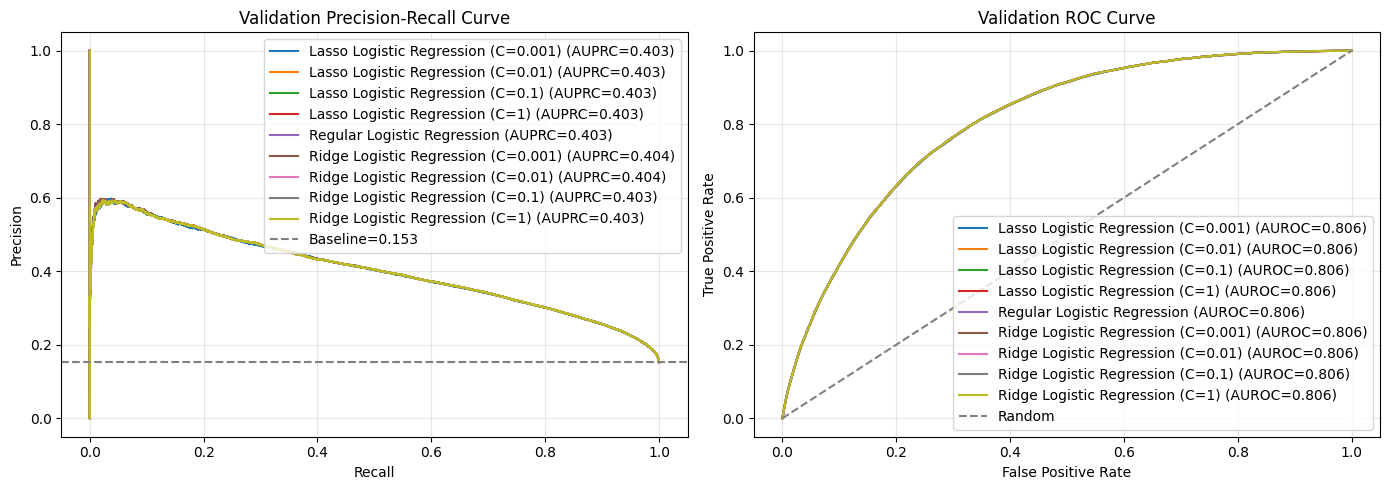

In [7]:
# ==========================================
# 6. Plot Validation Precision-Recall and ROC Curves
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, model_predictions in cv_predictions_df.groupby("Model"):
    y_valid = model_predictions["y_valid"]
    y_valid_proba = model_predictions["y_valid_proba"]

    fpr, tpr, _ = roc_curve(y_valid, y_valid_proba)
    precision, recall, _ = precision_recall_curve(y_valid, y_valid_proba)

    auroc = roc_auc_score(y_valid, y_valid_proba)
    auprc = average_precision_score(y_valid, y_valid_proba)

    axes[0].plot(recall, precision, label=f"{model_name} (AUPRC={auprc:.3f})")
    axes[1].plot(fpr, tpr, label=f"{model_name} (AUROC={auroc:.3f})")

baseline_precision = y_train.mean()

axes[0].axhline(baseline_precision, linestyle="--", color="gray", label=f"Baseline={baseline_precision:.3f}")
axes[0].set_title("Validation Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[1].set_title("Validation ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

In [8]:
# ==========================================
# 7. Compare Logistic Regression Coefficients
# ==========================================

coefficient_table = pd.DataFrame({"Feature Name": X_train.columns})

coefficient_columns = {"Regular Logistic Regression": "Beta in Logistic"}

for C in C_values:
    coefficient_columns[f"Lasso Logistic Regression (C={C})"] = f"Beta in Lasso C={C}"

for C in C_values:
    coefficient_columns[f"Ridge Logistic Regression (C={C})"] = f"Beta in Ridge C={C}"

for model_name, beta_column in coefficient_columns.items():
    estimator = clone(models[model_name])
    estimator.fit(X_train, y_train)
    coefficient_table[beta_column] = estimator[-1].coef_.ravel()

coefficient_table.round(6)

,Feature Name,Beta in Logistic,Beta in Lasso C=1,Beta in Lasso C=0.1,Beta in Lasso C=0.01,Beta in Lasso C=0.001,Beta in Ridge C=1,Beta in Ridge C=0.1,Beta in Ridge C=0.01,Beta in Ridge C=0.001
0,HighBP,0.356559,0.356525,0.356457,0.355785,0.349256,0.356556,0.356529,0.356251,0.353309
1,HighChol,0.283035,0.282943,0.282728,0.280595,0.260813,0.283030,0.282981,0.282497,0.277818
2,CholCheck,0.257505,0.257520,0.256731,0.248966,0.182098,0.257483,0.257281,0.255294,0.237709
3,BMI,0.465917,0.465667,0.465366,0.462385,0.432235,0.465897,0.465721,0.463965,0.447543
4,Smoker,-0.009491,-0.009352,-0.008991,-0.005391,0.000000,-0.009490,-0.009477,-0.009350,-0.008136
5,Stroke,0.033655,0.033802,0.033652,0.032168,0.018010,0.033656,0.033664,0.033741,0.034480
6,HeartDiseaseorAttack,0.069772,0.069968,0.069902,0.069249,0.064140,0.069776,0.069813,0.070187,0.073589
7,PhysActivity,-0.006774,-0.006761,-0.006593,-0.004919,0.000000,-0.006778,-0.006807,-0.007099,-0.009808
8,Fruits,-0.013935,-0.013877,-0.013667,-0.011570,0.000000,-0.013935,-0.013928,-0.013867,-0.013315
9,Veggies,-0.007392,-0.007321,-0.007206,-0.006060,0.000000,-0.007393,-0.007400,-0.007472,-0.008144


# Summary of model-selection results

So far, the regular logistic regression, Lasso logistic regression, and Ridge logistic regression models show very similar validation performance. This is reasonable for a few possible reasons. 
- The dataset is large, so the logistic regression estimates are stable. 
- The number of features is not very large, so the model is not operating in a high-dimensional setting where regularization would usually have a much stronger effect. 
- The features do not appear to cause severe overfitting in the unregularized logistic regression model. 
- Regularization changes the beta values, especially for stronger Lasso settings, but it does not substantially change the overall ordering of the most important features.

From the beta table, the features with the largest absolute coefficients include `GenHlth`, `BMI`, `Age`, `HighBP`, `HighChol`, and `CholCheck`. This is consistent with the patterns observed in the heat map from `01_eda_and_data_cleaning.ipynb`, where these variables also showed stronger relationships with diabetes status. In other words, the coefficient results support the same broad story we saw during EDA: general health, body mass index, age, blood pressure, cholesterol, and cholesterol screening are among the most informative predictors in this dataset.

Because the models behave similarly, we can use one representative model, `Ridge Logistic Regression (C=0.001)`, to study classification thresholds. This threshold analysis is mainly for business and medical decision-making, not for changing the model itself. In a medical screening context, a lower threshold may be preferred when missing a true diabetes case is more costly than sending more people for follow-up testing. Lower thresholds classify more people as positive, which usually increases recall but decreases precision. F1 helps summarize the balance between precision and recall at each threshold. AUROC and AUPRC are based on the ranking of predicted probabilities, so they remain the same across thresholds for the same model predictions.

In [9]:
# ==========================================
# 8. Selected Threshold Summary for Ridge Logistic Regression (C=0.001)
# ==========================================

selected_model = "Ridge Logistic Regression (C=0.001)"

ridge_predictions = cv_predictions_df.loc[
    cv_predictions_df["Model"] == selected_model
].copy()

y_valid = ridge_predictions["y_valid"]
y_valid_proba = ridge_predictions["y_valid_proba"]


def get_best_f2_threshold(y_true, y_score, beta=2):
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_score)
    beta_squared = beta ** 2
    numerator = (1 + beta_squared) * precision_curve[:-1] * recall_curve[:-1]
    denominator = beta_squared * precision_curve[:-1] + recall_curve[:-1]
    fbeta_scores = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator),
        where=denominator != 0,
    )
    return pr_thresholds[fbeta_scores.argmax()]


def get_best_tpr_fpr_threshold(y_true, y_score):
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    finite_threshold_mask = np.isfinite(roc_thresholds)
    fpr = fpr[finite_threshold_mask]
    tpr = tpr[finite_threshold_mask]
    roc_thresholds = roc_thresholds[finite_threshold_mask]
    best_index = (tpr - fpr).argmax()
    return roc_thresholds[best_index], tpr[best_index] - fpr[best_index]


def summarize_threshold(y_true, y_score, threshold, selection_rule):
    y_pred = (y_score >= threshold).astype(int)
    true_negative = ((y_true == 0) & (y_pred == 0)).sum()
    false_positive = ((y_true == 0) & (y_pred == 1)).sum()
    false_positive_rate = false_positive / (false_positive + true_negative)
    true_positive_rate = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    return {
        "Selection Rule": selection_rule,
        "Model": selected_model,
        "Threshold": threshold,
        "Validation Recall": true_positive_rate,
        "Validation Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Validation F1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Validation F2": fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0),
        "Validation AUPRC": average_precision_score(y_true, y_score),
        "Validation AUROC": roc_auc_score(y_true, y_score),
        "Predicted Positive Rate": y_pred.mean(),
        "TPR - FPR": true_positive_rate - false_positive_rate,
    }


default_threshold = 0.5
best_f2_threshold = get_best_f2_threshold(y_valid, y_valid_proba, beta=2)
best_tpr_fpr_threshold, best_tpr_fpr_score = get_best_tpr_fpr_threshold(y_valid, y_valid_proba)

selected_threshold_results_df = pd.DataFrame([
    summarize_threshold(y_valid, y_valid_proba, default_threshold, "Default threshold"),
    summarize_threshold(y_valid, y_valid_proba, best_f2_threshold, "Max F2 threshold"),
    summarize_threshold(
        y_valid,
        y_valid_proba,
        best_tpr_fpr_threshold,
        "Max TPR-FPR threshold"
    ),
])

selected_threshold_results_df.round(6)


,Selection Rule,Model,Threshold,Validation Recall,Validation Precision,Validation F1,Validation F2,Validation AUPRC,Validation AUROC,Predicted Positive Rate,TPR - FPR
0,Default threshold,Ridge Logistic Regression (C=0.001),0.500000,0.752751,0.319139,0.448241,0.591907,0.404043,0.806408,0.360263,0.463243
1,Max F2 threshold,Ridge Logistic Regression (C=0.001),0.406538,0.846066,0.281865,0.422856,0.604188,0.404043,0.806408,0.458471,0.457468
2,Max TPR-FPR threshold,Ridge Logistic Regression (C=0.001),0.457273,0.799124,0.301987,0.438330,0.601186,0.404043,0.806408,0.404180,0.466142


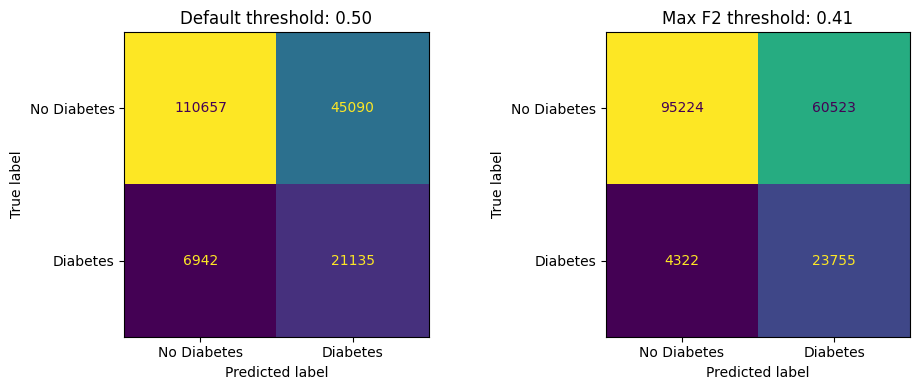

In [10]:
# ==========================================
# 9. Confusion Matrices for Selected Thresholds
# ==========================================

confusion_thresholds = [
    ("Default threshold", default_threshold),
    ("Max F2 threshold", best_f2_threshold),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (label, threshold) in zip(axes.ravel(), confusion_thresholds):
    y_valid_pred = (y_valid_proba >= threshold).astype(int)
    cm = confusion_matrix(y_valid, y_valid_pred, labels=[0, 1])

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Diabetes", "Diabetes"]
    )
    display.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{label}: {threshold:.2f}")

plt.tight_layout()
